Final SNN Implementation (Paper-Reproduced)

# Group 63 — record-linkage baseline notebook
Finalised review copy

**Output provenance:** saved outputs are retained from Fayyaz’s completed local run before the naming/documentation cleanup below. This final copy has been syntax-checked, not re-executed. Run top to bottom in `snn-env` for a new reproducible execution order; numerical results may vary because model training is stochastic. Keep the notebook in the repository root beside `Datasets/` and `Embeddings/`.

These are record-linkage results, not membership-inference results. K-shadow-model development is still pending.


In [18]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import BertTokenizer, TFBertModel
import arff
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [19]:
# ==========================
# Step 1: Load data
# ===========================


train_df=pd.read_csv("Datasets/target_train.csv")
test_df=pd.read_csv("Datasets/target_test.csv")

# sample_matching_df = pairwise_df[pairwise_df['label'] == 1].sample(n=50000, random_state=42)
# sample_nonmatching_df = pairwise_df[pairwise_df['label'] == 0].sample(n=50000, random_state=42)
# sample_df = pd.concat([sample_matching_df, sample_nonmatching_df]).reset_index(drop=True)

# # Optionally, print sample_df to inspect
 #print("Sampled record pairs:")
 #print(sample_df[['uid1', 'uid2', 'label']].head())

# Step 3: Generate embeddings only for train and test separately
import numpy as np
from transformers import BertTokenizer, TFBertModel
import tensorflow as tf
from tqdm import tqdm

# Load pretrained BERT model and tokenizer
from transformers import BertTokenizer, TFBertModel

# Load ClinicalBERT
tokenizer = BertTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
bert_model = TFBertModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")


# Helper function for batched embedding generation
def generate_embeddings_batched(texts, batch_size=32, max_length=512):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts.iloc[i:i+batch_size].tolist()
        inputs = tokenizer(
            batch,
            return_tensors="tf",
            padding=True,
            truncation=True,
            max_length=max_length  # Truncate to 512 tokens
        )
        outputs = bert_model(inputs["input_ids"])
        cls_embeddings = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        all_embeddings.append(cls_embeddings.numpy())

    return np.vstack(all_embeddings)
# Encode and save embeddings
x1_train = generate_embeddings_batched(train_df['text1'])
x2_train = generate_embeddings_batched(train_df['text2'])
y_train = train_df['label'].values.astype(np.float32)

x1_test = generate_embeddings_batched(test_df['text1'])
x2_test = generate_embeddings_batched(test_df['text2'])
y_test = test_df['label'].values.astype(np.float32)

In [3]:
# Directory to store cached files
# os.makedirs("clinicalbert", exist_ok=True)
# # save the embeddings for later use
# np.save("clinicalbert/x1_train.npy", x1_train)
# np.save("clinicalbert/x2_train.npy", x2_train)
# np.save("clinicalbert/y_train.npy", y_train)
# np.save("clinicalbert/x1_test.npy", x1_test)
# np.save("clinicalbert/x2_test.npy", x1_test)
# np.save("clinicalbert/y_test.npy", y_test)

# # For the later experiments load the embeddings using following code
# x1_train = np.load("clinicalbert/x1_train.npy")
# x2_train = np.load("clinicalbert/x2_train.npy")
# y_train = np.load("clinicalbert/y_train.npy")
# x1_test = np.load("clinicalbert/x1_test.npy")
# x2_test = np.load("clinicalbert/x2_test.npy")
# y_test = np.load("clinicalbert/y_test.npy")



# # === Load precomputed BERT embeddings ===
# Load precomputed target embeddings from Embeddings/
x1_train = np.load("Embeddings/x1_target_train.npy")
x2_train = np.load("Embeddings/x2_target_train.npy")
y_train = np.load("Embeddings/y_target_train.npy")

x1_test = np.load("Embeddings/x1_target_test.npy")
x2_test = np.load("Embeddings/x2_target_test.npy")
y_test = np.load("Embeddings/y_target_test.npy")

print(f"Loaded Target Train: x1={x1_train.shape}, y={y_train.shape}")
print(f"Loaded Target Test:  x1={x1_test.shape}, y={y_test.shape}")
print(
    "Mean difference between x1_test and x2_test:",
    np.mean(np.abs(x1_test - x2_test)),
)

# Fixed assertion
assert not np.allclose(
    x1_test, x2_test
), "x1_test and x2_test appear to be identical!"
# Load precomputed shadow embeddings from Embeddings/
x1_shadow_train = np.load("Embeddings/x1_shadow_train.npy")
x2_shadow_train = np.load("Embeddings/x2_shadow_train.npy")
y_shadow_train = np.load("Embeddings/y_shadow_train.npy")

x1_shadow_test = np.load("Embeddings/x1_shadow_test.npy")
x2_shadow_test = np.load("Embeddings/x2_shadow_test.npy")
y_shadow_test = np.load("Embeddings/y_shadow_test.npy")

print(
    f"Loaded Shadow Train: x1={x1_shadow_train.shape}, y={y_shadow_train.shape}"
)
print(f"Loaded Shadow Test:  x1={x1_shadow_test.shape}, y={y_shadow_test.shape}")


Loaded Target Train: x1=(32000, 768), y=(32000,)
Loaded Target Test:  x1=(8000, 768), y=(8000,)
Mean difference between x1_test and x2_test: 0.19689083
Loaded Shadow Train: x1=(32000, 768), y=(32000,)
Loaded Shadow Test:  x1=(8000, 768), y=(8000,)


In [5]:
# Validate all loaded embeddings before training
splits = {
    "Target train": (x1_train, x2_train, y_train),
    "Target test": (x1_test, x2_test, y_test),
    "Shadow train": (x1_shadow_train, x2_shadow_train, y_shadow_train),
    "Shadow test": (x1_shadow_test, x2_shadow_test, y_shadow_test),
}

for name, (a, b, labels) in splits.items():
    assert a.ndim == b.ndim == 2, f"{name}: embeddings must be matrices"
    assert labels.ndim == 1, f"{name}: labels must be one-dimensional"
    assert a.shape == b.shape == (len(labels), 768), f"{name}: shape mismatch"
    assert np.isfinite(a).all() and np.isfinite(b).all(), f"{name}: NaN/Inf"
    assert np.isin(labels, [0, 1]).all(), f"{name}: invalid labels"

    values, counts = np.unique(labels, return_counts=True)
    print(f"{name}: {len(labels):,} pairs | labels: {dict(zip(values, counts))}")

print("All four splits passed structural checks.")

Target train: 32,000 pairs | labels: {0.0: 16031, 1.0: 15969}
Target test: 8,000 pairs | labels: {0.0: 4008, 1.0: 3992}
Shadow train: 32,000 pairs | labels: {0.0: 15969, 1.0: 16031}
Shadow test: 8,000 pairs | labels: {0.0: 3992, 1.0: 4008}
All four splits passed structural checks.


In [6]:
# Check target CSV labels against saved embedding labels
for split, saved_labels in [
    ("train", y_train),
    ("test", y_test),
]:
    df = pd.read_csv(f"Datasets/target_{split}.csv")
    csv_labels = pd.to_numeric(df["label"], errors="raise").to_numpy()

    assert len(df) == len(saved_labels), f"Target {split}: row count mismatch"

    mismatches = np.count_nonzero(csv_labels != saved_labels)
    print(f"Target {split}: {mismatches} label mismatches")
    assert mismatches == 0, f"Target {split}: labels do not align"

print("Target CSV and saved labels agree row by row.")

Target train: 0 label mismatches
Target test: 0 label mismatches
Target CSV and saved labels agree row by row.


In [7]:
# ====================================
# Step 3: Build Siamese Autoencoder
# ====================================
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
def build_siamese_autoencoder(embedding_dim):
    encoder_input = Input(shape=(embedding_dim,))
    x = layers.Dense(50, activity_regularizer=regularizers.l1(0.01))(encoder_input)
    x = layers.LeakyReLU(alpha=0.01)(x)
    encoder_output = layers.Dense(embedding_dim, activation='relu')(x)
    encoder = Model(encoder_input, encoder_output)

    decoder_input = Input(shape=(embedding_dim,))
    decoder_output = layers.Dense(embedding_dim, activation='sigmoid')(decoder_input)
    decoder = Model(decoder_input, decoder_output)

    input1 = Input(shape=(embedding_dim,))
    input2 = Input(shape=(embedding_dim,))
    encoded1 = encoder(input1)
    encoded2 = encoder(input2)
    recon1 = decoder(encoded1)
    recon2 = decoder(encoded2)

    merged_output = layers.Concatenate()([recon1, recon2])
    model = Model(inputs=[input1, input2], outputs=merged_output)
    return model, encoder

def hybrid_classification_loss(margin=2.5, alpha=1.0):
    def loss_fn(y_true, y_pred):
        emb_dim = tf.shape(y_pred)[1] // 2
        recon1 = y_pred[:, :emb_dim]
        recon2 = y_pred[:, emb_dim:]

        squared_difference = tf.square(recon1 - recon2)
        recon_loss = tf.reduce_mean(squared_difference, axis=1)
        squared_distance = tf.reduce_sum(squared_difference, axis=1)

        distances = tf.sqrt(
            tf.maximum(squared_distance, tf.keras.backend.epsilon())
        )

        # One label per pair, regardless of incoming label shape.
        labels = tf.reshape(tf.cast(y_true, y_pred.dtype), [-1])
        tf.debugging.assert_equal(
            tf.shape(labels)[0], tf.shape(y_pred)[0]
        )

        contrastive_loss = (
            labels * squared_distance
            + (1 - labels) * tf.square(tf.maximum(margin - distances, 0))
        )

        return tf.reduce_mean(alpha * recon_loss + contrastive_loss)

    return loss_fn

In [8]:
# ==========================================================
# Evaluate the Siamese Autoencoder (Threshold-based)
# ==========================================================

# Get reconstructions
encoded1_train = encoder.predict(x1_train)
encoded2_train = encoder.predict(x2_train)
encoded1_test = encoder.predict(x1_test)
encoded2_test = encoder.predict(x2_test)

# Compute Euclidean distances
train_distances = np.sqrt(np.sum((encoded1_train - encoded2_train)**2, axis=1))
test_distances = np.sqrt(np.sum((encoded1_test - encoded2_test)**2, axis=1))

# Use fixed threshold (e.g., 1.0) to classify matches
threshold = 1.0
train_pred = (train_distances < threshold).astype(int)
test_pred = (test_distances < threshold).astype(int)

# Accuracy & F1
train_acc = accuracy_score(y_train, train_pred)
train_f1 = f1_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)

print("------ Siamese Autoencoder Evaluation ------")
print(f"Training Accuracy: {train_acc:.4f}, F1 Score: {train_f1:.4f}")
print(f"Test Accuracy: {test_acc:.4f}, F1 Score: {test_f1:.4f}")


250/250 [==============================] - 0s 1ms/step
------ Siamese Autoencoder Evaluation ------
Training Accuracy: 0.5166, F1 Score: 0.6458
Test Accuracy: 0.5268, F1 Score: 0.6457


In [9]:
# ====================================
# Step 4: Add Classification Head
# ====================================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate

# Step 1: Get encoded outputs
encoded1_train = encoder.predict(x1_train)
encoded2_train = encoder.predict(x2_train)
encoded1_test = encoder.predict(x1_test)
encoded2_test = encoder.predict(x2_test)

# Step 2: Compute absolute differences (Siamese-style)
diff_train = np.abs(encoded1_train - encoded2_train)
diff_test = np.abs(encoded1_test - encoded2_test)

# Step 3: Build classification model
input_diff = Input(shape=(diff_train.shape[1],))
x = Dense(64, activation='relu')(input_diff)
x = Dense(32, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)
clf_model = Model(inputs=input_diff, outputs=output)

clf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 4: Train the classifier
clf_model.fit(diff_train, y_train, epochs=20, batch_size=256, validation_split=0.1)

# Step 5: Evaluate
y_pred_prob = clf_model.predict(diff_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

from sklearn.metrics import accuracy_score, f1_score, classification_report

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nClassifier Evaluation:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nDetailed report:\n", classification_report(y_test, y_pred))


250/250 [==============================] - 0s 1ms/step
Epoch 1/20
113/113 [==============================] - 1s 5ms/step - loss: 0.5503 - accuracy: 0.7435 - val_loss: 0.4757 - val_accuracy: 0.7828
Epoch 2/20
113/113 [==============================] - 0s 3ms/step - loss: 0.4684 - accuracy: 0.7869 - val_loss: 0.4562 - val_accuracy: 0.7991
Epoch 3/20
113/113 [==============================] - 0s 3ms/step - loss: 0.4501 - accuracy: 0.7973 - val_loss: 0.4456 - val_accuracy: 0.8062
Epoch 4/20
113/113 [==============================] - 0s 4ms/step - loss: 0.4401 - accuracy: 0.8042 - val_loss: 0.4493 - val_accuracy: 0.8034
Epoch 5/20
113/113 [==============================] - 0s 4ms/step - loss: 0.4356 - accuracy: 0.8048 - val_loss: 0.4462 - val_accuracy: 0.8041
Epoch 6/20
113/113 [==============================] - 0s 4ms/step - loss: 0.4314 - accuracy: 0.8075 - val_loss: 0.4399 - val_accuracy: 0.8109
Epoch 7/20
113/113 [==============================] - 0s 4ms/step - loss: 0.4287 - accuracy: 

250/250 [==============================] - 0s 2ms/step
Classifier Accuracy: 0.78675
Classifier F1 Score: 0.7923563777994157
Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      0.76      0.78      4008
         1.0       0.77      0.82      0.79      3992

    accuracy                           0.79      8000
   macro avg       0.79      0.79      0.79      8000
weighted avg       0.79      0.79      0.79      8000



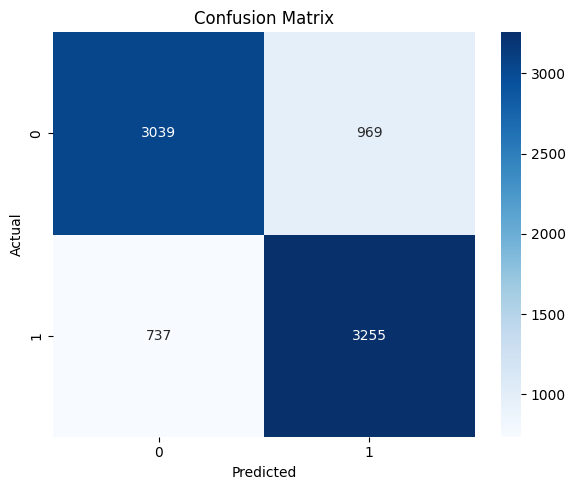

f:\python\envs\snn-env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [14]:
# ====================================
# Step 5: Evaluation and Visualization
# ====================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

y_pred_prob = clf_model.predict(diff_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Classifier Accuracy:", acc)
print("Classifier F1 Score:", f1)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

# Save Model
clf_model.save("snn_classifier_model.h5")

In [15]:
print("Train label distribution:")
print(pd.Series(y_train).value_counts())


Train label distribution:
0.0    16031
1.0    15969
Name: count, dtype: int64


In [16]:
# =========================================
# learn threshold from validation set
# ========================================

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras import regularizers
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, f1_score, classification_report
import numpy as np
# -------------------------------------------------------
# Step 1: Create pseudo-validation set from training data
# -------------------------------------------------------
diff_train_full = np.abs(x1_train - x2_train)
diff_test = np.abs(x1_test - x2_test)

# Split 80% train / 20% val for threshold tuning
diff_train_final, diff_val, y_train_final, y_val = train_test_split(
    diff_train_full, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# -------------------------------------------------------
# Step 2: Build and Train MLP Classifier
# -------------------------------------------------------
input_diff = Input(shape=(diff_train_final.shape[1],))
x = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(input_diff)
x = Dropout(0.5)(x)
x = Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
output = Dense(1, activation='sigmoid')(x)
clf_model = Model(inputs=input_diff, outputs=output)

clf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
clf_model.fit(diff_train_final, y_train_final, epochs=30, batch_size=256, validation_split=0.1)

# -------------------------------------------------------
# Step 3: Tune threshold on the validation set
# -------------------------------------------------------
y_val_prob = clf_model.predict(diff_val).flatten()

best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.1, 0.9, 0.01):
    y_pred_val = (y_val_prob >= threshold).astype(int)
    _, _, f1, _ = precision_recall_fscore_support(y_val, y_pred_val, average='binary')
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\n Best Threshold (on pseudo-val set): {best_threshold:.2f} — Best F1 Score: {best_f1:.4f}")

# -------------------------------------------------------
# Step 4: Evaluate on the true test set using tuned threshold
# -------------------------------------------------------
y_test_prob = clf_model.predict(diff_test).flatten()
y_test_pred = (y_test_prob >= best_threshold).astype(int)

acc = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("\n Final Evaluation on Test Set:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nDetailed Report:\n", classification_report(y_test, y_test_pred))

# Save predictions
import pandas as pd
pd.DataFrame({
    "True Label": y_test,
    "Predicted Label": y_test_pred,
    "Confidence": y_test_prob
}).to_csv("final_test_predictions.csv", index=False)
print(" Test predictions saved to 'final_test_predictions.csv'")


Epoch 1/30
90/90 [==============================] - 1s 5ms/step - loss: 1.2754 - accuracy: 0.7329 - val_loss: 0.7366 - val_accuracy: 0.8074
Epoch 2/30
90/90 [==============================] - 0s 4ms/step - loss: 0.6097 - accuracy: 0.8487 - val_loss: 0.4853 - val_accuracy: 0.8797
Epoch 3/30
90/90 [==============================] - 0s 4ms/step - loss: 0.4764 - accuracy: 0.8625 - val_loss: 0.4289 - val_accuracy: 0.8832
Epoch 4/30
90/90 [==============================] - 0s 4ms/step - loss: 0.4274 - accuracy: 0.8689 - val_loss: 0.3840 - val_accuracy: 0.8871
Epoch 5/30
90/90 [==============================] - 1s 6ms/step - loss: 0.4023 - accuracy: 0.8724 - val_loss: 0.3749 - val_accuracy: 0.8836
Epoch 6/30
90/90 [==============================] - 0s 4ms/step - loss: 0.3850 - accuracy: 0.8772 - val_loss: 0.3715 - val_accuracy: 0.8844
Epoch 7/30
90/90 [==============================] - 0s 3ms/step - loss: 0.3738 - accuracy: 0.8799 - val_loss: 0.3553 - val_accuracy: 0.8879
Epoch 8/30
90/90 [==

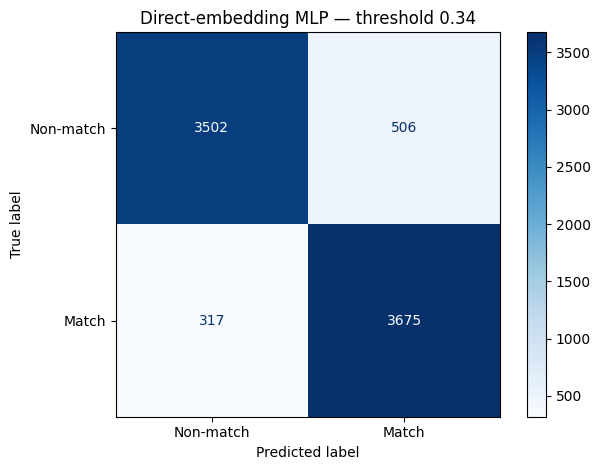

Saved final model, threshold, metrics and matching confusion matrix.


In [17]:
# Save and visualise the final direct-embedding MLP separately.
from pathlib import Path
import json
from sklearn.metrics import ConfusionMatrixDisplay

results_dir = Path("results") / "direct_embedding_mlp"
results_dir.mkdir(parents=True, exist_ok=True)

final_mlp = clf_model
final_threshold = float(best_threshold)
final_predictions = (y_test_prob >= final_threshold).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions,
    display_labels=["Non-match", "Match"],
    cmap="Blues",
    values_format="d"
)
plt.title(f"Direct-embedding MLP — threshold {final_threshold:.2f}")
plt.tight_layout()
plt.savefig(results_dir / "confusion_matrix.png", dpi=150)
plt.show()

final_mlp.save(str(results_dir / "model.keras"))

metrics = {
    "model": "MLP on absolute differences of original BERT embeddings",
    "task": "record linkage",
    "threshold": final_threshold,
    "test_accuracy": float(accuracy_score(y_test, final_predictions)),
    "test_f1": float(f1_score(y_test, final_predictions)),
    "test_pairs": int(len(y_test))
}

with open(results_dir / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved final model, threshold, metrics and matching confusion matrix.")

In [ ]:
## To be added, K attack models 